# MNIST RGB Diffusion Model 全流程
本 Notebook 依據作業需求，從頭建立一個 MNIST RGB 版的 Diffusion 模型（DDPM 架構），包含資料載入、模型定義、訓練、影像生成、壓縮與 FID 評估。

## 環境與必要套件
以下指令會安裝（或確認）PyTorch、torchvision、pytorch-fid 等必要套件。若已安裝，可直接跳過執行。

In [1]:
# 若環境已具備這些套件，可跳過此步驟
# %pip install torch torchvision pytorch-fid tqdm tensorboardX pillow -q

## 設定資料與輸出路徑


In [2]:
from pathlib import Path

# 依照作業規範的資料夾結構設定路徑
DATASET_DIR = Path('minst')               # MNIST RGB 60,000 張 PNG
MNIST_STATS = Path('mnist.npz')           # 官方提供的 mean/cov 檔
CHECKPOINT_DIR = Path('checkpoints')
SAMPLE_PREVIEW_DIR = Path('samples_preview')
FINAL_OUTPUT_DIR = Path('generated_images')

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_PREVIEW_DIR.mkdir(parents=True, exist_ok=True)
FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = {
    'image_size': 28,
    'batch_size': 1024,
    'epochs': 50,
    'lr': 2e-4,
    'timesteps': 1000,
    'beta_start': 1e-4,
    'beta_end': 0.02,
    'num_workers': 4,
    'base_channels': 64,
    'channel_mults': (1, 2, 4),
    'preview_samples': 64,
    'sample_batch_size': 128,
    'num_generate': 10000,
}
config

{'image_size': 28,
 'batch_size': 1024,
 'epochs': 50,
 'lr': 0.0002,
 'timesteps': 1000,
 'beta_start': 0.0001,
 'beta_end': 0.02,
 'num_workers': 4,
 'base_channels': 64,
 'channel_mults': (1, 2, 4),
 'preview_samples': 64,
 'sample_batch_size': 128,
 'num_generate': 10000}

## 匯入函式庫與裝置偵測


In [3]:
import math
import os
import random

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import save_image
from tqdm import tqdm
from PIL import Image

from pytorch_fid import fid_score

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 建立 MNIST PNG Dataset 讀取類別
遍歷指定資料夾底下的所有 PNG，轉為 28×28 的 RGB Tensor，並做 [-1, 1] 的標準化，以符合 DDPM 的輸入要求。

In [4]:
class PNGImageDataset(Dataset):
    """讀取平面資料夾中的連續 PNG 影像並轉為 Tensor。"""

    def __init__(self, root: Path, image_size: int = 28):
        self.root = root
        self.files = sorted([p for p in root.glob('*.png') if p.is_file()])
        if not self.files:
            raise ValueError(f'資料夾 {root} 中找不到 PNG 檔案')
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        return self.transform(img)

# 測試 dataset 是否可行
sample_dataset = PNGImageDataset(DATASET_DIR, image_size=config['image_size'])
len(sample_dataset)

60000

## UNet 模型實作
以下程式碼從零開始實作 UNet 型 DDPM 所需要的模組：時間嵌入、殘差方塊、下/上採樣層，最後組成完整的 UNet 網路。

In [5]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        device = timesteps.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = timesteps[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        if self.dim % 2 == 1:
            emb = torch.nn.functional.pad(emb, (0, 1))
        return emb


class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, time_emb_dim: int, groups: int = 8):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.GroupNorm(groups, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
        )
        self.time_emb = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels),
        )
        self.residual = (
            nn.Conv2d(in_channels, out_channels, 1)
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        h = self.block1(x)
        time_emb = self.time_emb(t)[:, :, None, None]
        h = h + time_emb
        h = self.block2(h)
        return h + self.residual(x)


class Downsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, img_channels: int = 3, base_channels: int = 64, channel_mults=(1, 2, 4), time_emb_dim: int = 256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim * 4),
        )
        self.time_dim = time_emb_dim * 4
        self.conv_in = nn.Conv2d(img_channels, base_channels, 3, padding=1)

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.skip_channels = []

        curr_channels = base_channels
        for i, mult in enumerate(channel_mults):
            out_channels = base_channels * mult
            self.downs.append(
                nn.ModuleList([
                    ResidualBlock(curr_channels, out_channels, self.time_dim),
                    ResidualBlock(out_channels, out_channels, self.time_dim),
                    Downsample(out_channels) if i < len(channel_mults) - 1 else nn.Identity(),
                ])
            )
            self.skip_channels.append(out_channels)
            curr_channels = out_channels

        self.mid_block1 = ResidualBlock(curr_channels, curr_channels, self.time_dim)
        self.mid_block2 = ResidualBlock(curr_channels, curr_channels, self.time_dim)

        for i, mult in reversed(list(enumerate(channel_mults))):
            out_channels = base_channels * mult
            self.ups.append(
                nn.ModuleList([
                    ResidualBlock(curr_channels + self.skip_channels[i], out_channels, self.time_dim),
                    ResidualBlock(out_channels, out_channels, self.time_dim),
                    Upsample(out_channels) if i > 0 else nn.Identity(),
                ])
            )
            curr_channels = out_channels

        self.output = nn.Sequential(
            nn.GroupNorm(8, curr_channels),
            nn.SiLU(),
            nn.Conv2d(curr_channels, img_channels, 3, padding=1),
        )

    def forward(self, x: torch.Tensor, time: torch.Tensor) -> torch.Tensor:
        t = self.time_mlp(time)
        h = self.conv_in(x)
        skips = []
        for res1, res2, down in self.downs:
            h = res1(h, t)
            h = res2(h, t)
            skips.append(h)
            h = down(h)

        h = self.mid_block1(h, t)
        h = self.mid_block2(h, t)

        for res1, res2, up in self.ups:
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = res1(h, t)
            h = res2(h, t)
            h = up(h)

        return self.output(h)

model = UNet(img_channels=3, base_channels=config['base_channels'], channel_mults=config['channel_mults']).to(device)
model(torch.randn(1, 3, config['image_size'], config['image_size'], device=device), torch.randint(0, 1000, (1,), device=device).long()).shape

torch.Size([1, 3, 28, 28])

## Diffusion 過程定義
下列程式碼實作前向加噪（q）與反向還原（p），包含 beta 行程、取樣輔助函式、以及整體的 `GaussianDiffusion` 模組。

In [6]:
def make_beta_schedule(timesteps: int, beta_start: float, beta_end: float):
    return torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float32)


def extract(a: torch.Tensor, t: torch.Tensor, x_shape: torch.Size):
    batch_size = t.shape[0]
    out = a.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))


class GaussianDiffusion(nn.Module):
    def __init__(self, model: nn.Module, image_size: int = 28, channels: int = 3, timesteps: int = 1000, beta_start: float = 1e-4, beta_end: float = 0.02):
        super().__init__()
        self.model = model
        self.image_size = image_size
        self.channels = channels
        self.timesteps = timesteps

        betas = make_beta_schedule(timesteps, beta_start, beta_end)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]], dim=0)

        self.register_buffer('betas', betas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('alphas_cumprod_prev', alphas_cumprod_prev)
        self.register_buffer('sqrt_alphas_cumprod', torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus_alphas_cumprod', torch.sqrt(1.0 - alphas_cumprod))
        self.register_buffer('sqrt_recip_alphas', torch.sqrt(1.0 / alphas))
        self.register_buffer('posterior_variance', betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod))

    def q_sample(self, x_start: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_alpha = extract(self.sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus = extract(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape)
        return sqrt_alpha * x_start + sqrt_one_minus * noise

    def p_losses(self, x_start: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        if noise is None:
            noise = torch.randn_like(x_start)
        x_noisy = self.q_sample(x_start, t, noise)
        predicted_noise = self.model(x_noisy, t)
        return torch.nn.functional.mse_loss(predicted_noise, noise)

    @torch.no_grad()
    def p_sample(self, x: torch.Tensor, t: torch.Tensor):
        betas_t = extract(self.betas, t, x.shape)
        sqrt_one_minus = extract(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
        sqrt_recip_alpha = extract(self.sqrt_recip_alphas, t, x.shape)

        model_mean = sqrt_recip_alpha * (x - betas_t / sqrt_one_minus * self.model(x, t))
        noise = torch.randn_like(x)
        posterior_variance = extract(self.posterior_variance, t, x.shape)
        nonzero_mask = (t != 0).float().reshape(x.shape[0], *((1,) * (x.ndim - 1)))
        return model_mean + nonzero_mask * torch.sqrt(posterior_variance) * noise

    @torch.no_grad()
    def sample(self, batch_size: int, device: torch.device):
        img = torch.randn(batch_size, self.channels, self.image_size, self.image_size, device=device)
        for i in reversed(range(self.timesteps)):
            t = torch.full((batch_size,), i, device=device, dtype=torch.long)
            img = self.p_sample(img, t)
        return img


diffusion = GaussianDiffusion(model, image_size=config['image_size'], timesteps=config['timesteps'], beta_start=config['beta_start'], beta_end=config['beta_end']).to(device)
diffusion.q_sample(torch.randn(2, 3, config['image_size'], config['image_size'], device=device), torch.randint(0, config['timesteps'], (2,), device=device))

tensor([[[[-1.2721, -0.0290, -0.0982,  ..., -0.2152,  0.7448,  0.1738],
          [ 0.2374,  0.4926,  0.5803,  ...,  0.1941,  0.8147, -0.6914],
          [-0.0865,  0.7619,  0.6374,  ...,  0.8418, -1.0985,  1.4942],
          ...,
          [-0.5774, -0.6836,  0.1984,  ...,  0.2891,  1.4543,  0.8443],
          [ 0.3082, -0.5633,  0.2780,  ..., -1.3840, -1.8435,  1.4929],
          [ 1.5888, -1.6992,  0.4472,  ..., -0.9463, -2.4662,  1.6675]],

         [[ 1.7434,  0.9911,  0.0038,  ..., -2.0875,  1.4899,  0.5304],
          [-1.4622, -0.5468,  1.6646,  ...,  1.5082, -0.2222,  0.0364],
          [ 1.3409, -0.2177,  0.8620,  ..., -1.2513, -1.0183, -1.6667],
          ...,
          [ 0.4526, -0.1006, -1.1037,  ..., -0.1704,  1.6331,  0.5130],
          [ 0.8970,  0.2034,  1.1685,  ...,  1.7423,  0.6383,  0.3456],
          [ 0.8254, -0.7107, -0.2741,  ...,  0.8735,  1.1722,  0.8498]],

         [[ 0.0101, -0.6573, -0.5163,  ...,  0.4181,  0.1594, -1.0914],
          [-0.7120, -1.4641,  

## 訓練與生成輔助函式
1. 建立 DataLoader。
2. 完整訓練流程（含 checkpoint 保存）。
3. 影像生成函式，確保輸出檔名為 00001.png ~ 10000.png。

In [7]:
def get_dataloader(batch_size: int, num_workers: int):
    dataset = PNGImageDataset(DATASET_DIR, image_size=config['image_size'])
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)


def train_model(epochs: int = 200):
    dataloader = get_dataloader(config['batch_size'], config['num_workers'])
    unet = UNet(img_channels=3, base_channels=config['base_channels'], channel_mults=config['channel_mults']).to(device)
    diffusion = GaussianDiffusion(unet, image_size=config['image_size'], timesteps=config['timesteps'], beta_start=config['beta_start'], beta_end=config['beta_end']).to(device)
    optimizer = optim.Adam(unet.parameters(), lr=config['lr'])

    for epoch in range(epochs):
        unet.train()
        progress = tqdm(dataloader, desc=f'Epoch {epoch + 1}/{epochs}')
        for batch in progress:
            batch = batch.to(device, non_blocking=True)
            optimizer.zero_grad()
            t = torch.randint(0, diffusion.timesteps, (batch.size(0),), device=device).long()
            loss = diffusion.p_losses(batch, t)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
            optimizer.step()
            progress.set_postfix(loss=f'{loss.item():.4f}')

        ckpt_path = CHECKPOINT_DIR / f'model_epoch_{epoch + 1}.pt'
        torch.save({'model': unet.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': epoch + 1}, ckpt_path)

        if (epoch + 1) % 10 == 0:
            preview_dir = SAMPLE_PREVIEW_DIR / f'epoch_{epoch + 1}'
            preview_dir.mkdir(parents=True, exist_ok=True)
            generate_images(diffusion, preview_dir, config['preview_samples'], config['sample_batch_size'])

    final_ckpt = CHECKPOINT_DIR / 'model_final.pt'
    torch.save({'model': unet.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': epochs}, final_ckpt)
    return diffusion


def generate_images(diffusion_model: GaussianDiffusion, output_dir: Path, total_images: int, batch_size: int = 256, start_index: int = 1):
    output_dir.mkdir(parents=True, exist_ok=True)
    produced = 0
    next_index = start_index
    while produced < total_images:
        current_batch = min(batch_size, total_images - produced)
        samples = diffusion_model.sample(current_batch, device)
        samples = torch.clamp((samples + 1) / 2, 0.0, 1.0)
        for i in range(current_batch):
            save_image(samples[i], output_dir / f'{next_index:05d}.png')
            next_index += 1
        produced += current_batch

## 執行訓練

In [ ]:
RUN_TRAINING = True
trained_diffusion = None

if RUN_TRAINING:
    trained_diffusion = train_model(epochs=config['epochs'])
else:
    print('尚未啟動訓練，將在載入 checkpoint 後才能生成影像。')

Epoch 50/50: 100%|██████████| 59/59 [00:15<00:00,  3.84it/s, loss=0.0109]


## 從 Checkpoint 載入模型並生成 10,000 張影像
可從 `model_final.pt`（或任意 epoch）載入權重

In [10]:
def load_model_from_checkpoint(checkpoint_path: Path):
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'找不到 checkpoint: {checkpoint_path}')
    unet = UNet(img_channels=3, base_channels=config['base_channels'], channel_mults=config['channel_mults']).to(device)
    state = torch.load(checkpoint_path, map_location=device)
    unet.load_state_dict(state['model'])
    diffusion = GaussianDiffusion(unet, image_size=config['image_size'], timesteps=config['timesteps'], beta_start=config['beta_start'], beta_end=config['beta_end']).to(device)
    return diffusion

checkpoint_path = CHECKPOINT_DIR / 'model_final.pt'
# checkpoint_path = CHECKPOINT_DIR / 'model_epoch_29.pt'  # --- IGNORE ---
RUN_GENERATION = True

if RUN_GENERATION:
    diffusion_model = trained_diffusion if trained_diffusion is not None else load_model_from_checkpoint(checkpoint_path)
    generate_images(diffusion_model, FINAL_OUTPUT_DIR, config['num_generate'], batch_size=config['sample_batch_size'])
    print('生成完成，檔案位於', FINAL_OUTPUT_DIR)
else:
    print('尚未啟動生成，請將 RUN_GENERATION 改為 True')

/tmp/ipykernel_2447/3115273450.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location=device)


生成完成，檔案位於 generated_images


## 壓縮生成影像
將 10,000 張 PNG 壓縮成 zip

In [11]:
import shutil

ZIP_OUTPUT = Path('generated_images.zip')
RUN_ZIP = True

if RUN_ZIP:
    if FINAL_OUTPUT_DIR.exists():
        shutil.make_archive(FINAL_OUTPUT_DIR.name, 'zip', FINAL_OUTPUT_DIR)
        print(f'已建立 {ZIP_OUTPUT}')
    else:
        print('找不到生成影像資料夾，請先完成生成步驟')
else:
    print('尚未壓縮，如需壓縮請將 RUN_ZIP 設為 True')

已建立 generated_images.zip


## 使用 python -m pytorch_fid 指令計算 FID

In [12]:
import subprocess
import sys

cmd = [sys.executable, '-m', 'pytorch_fid', str(FINAL_OUTPUT_DIR), str(MNIST_STATS)]
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise SystemExit(result.returncode)

FID:  15.867068410182753



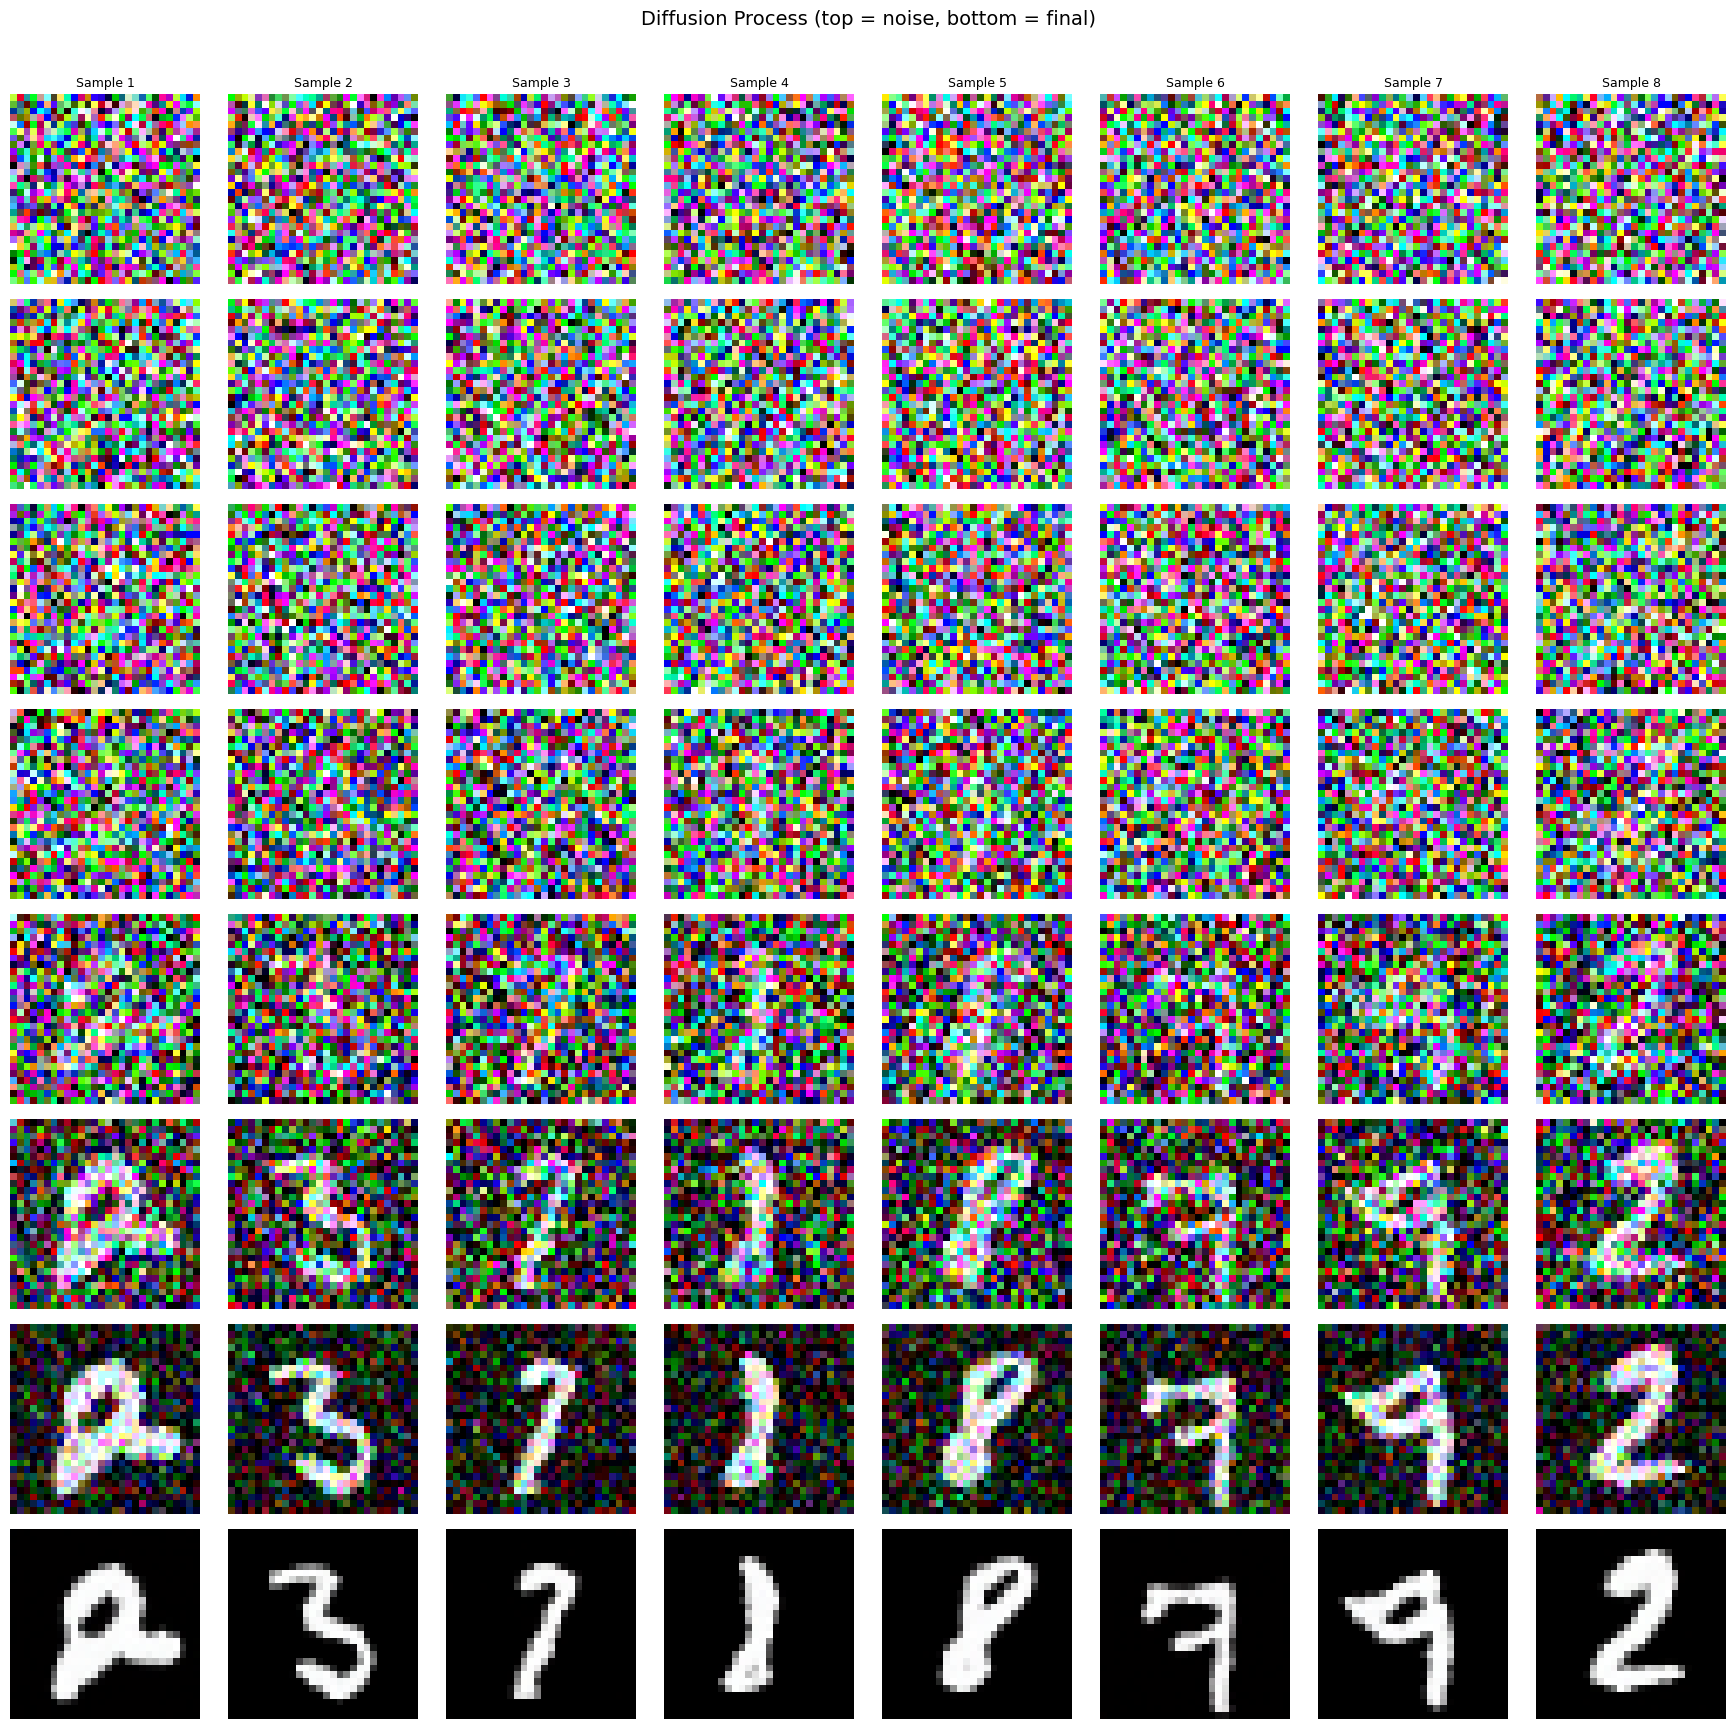

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_diffusion_process(diffusion_for_viz=None, num_variations: int = 8):
    """Visualize the reverse diffusion trajectory starting from pure noise (displayed top → bottom)."""
    if diffusion_for_viz is None:
        if 'diffusion_model' in globals() and diffusion_model is not None:
            diffusion_for_viz = diffusion_model
        elif 'trained_diffusion' in globals() and trained_diffusion is not None:
            diffusion_for_viz = trained_diffusion
        else:
            diffusion_for_viz = load_model_from_checkpoint(checkpoint_path)

    diffusion_for_viz.eval()
    device = next(diffusion_for_viz.parameters()).device
    total_steps = diffusion_for_viz.timesteps
    interval = max(1, total_steps // 7)
    milestone_steps = [0] + [min(total_steps, i * interval) for i in range(1, 7)] + [total_steps]

    deduped = []
    for step in milestone_steps:
        if deduped and step <= deduped[-1]:
            continue
        deduped.append(step)
    milestone_steps = deduped[:8]
    while len(milestone_steps) < 8:
        milestone_steps.append(total_steps)

    milestone_iter = iter(milestone_steps[1:])
    next_target = next(milestone_iter, None)
    snapshots = []

    img = torch.randn(num_variations, diffusion_for_viz.channels, diffusion_for_viz.image_size, diffusion_for_viz.image_size, device=device)
    snapshots.append(img.detach().cpu())
    steps_done = 0

    for current_t in reversed(range(total_steps)):
        t_tensor = torch.full((num_variations,), current_t, device=device, dtype=torch.long)
        img = diffusion_for_viz.p_sample(img, t_tensor)
        steps_done += 1
        while next_target is not None and steps_done >= next_target:
            snapshots.append(img.detach().cpu())
            next_target = next(milestone_iter, None)
        if len(snapshots) == len(milestone_steps):
            break

    num_rows = len(snapshots)
    num_cols = num_variations
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2.2, num_rows * 2.2))
    fig.suptitle('Diffusion Process (top = noise, bottom = final)', fontsize=14)

    axes = np.array(axes)
    if axes.ndim == 1:
        axes = axes[np.newaxis, :]
    axes = axes.reshape(num_rows, num_cols)

    def tensor_to_image(x: torch.Tensor):
        x = torch.clamp((x + 1) / 2, 0, 1)
        return x.permute(1, 2, 0).numpy()

    for row in range(num_rows):
        step_label = 'noise' if milestone_steps[row] == 0 else f'{milestone_steps[row]} steps'
        for col in range(num_cols):
            axes[row, col].imshow(tensor_to_image(snapshots[row][col]))
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(f'Sample {col + 1}', fontsize=9)
            if col == 0:
                axes[row, col].set_ylabel(step_label, rotation=0, labelpad=40, fontsize=9, va='center', ha='right')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


visualize_diffusion_process()
